In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
df_clean = pd.read_csv('../../data/df_clean.csv')
df_clean.columns = df_clean.columns.str.strip()

In [43]:
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

In [44]:
df_clean.head()

,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Coolant_Temp,Coolant_Pressure,Factory_Temp,Factory_Humidity,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,Scratch_1,Buring_Mark_1,Inclusions_1,Short_Shot_2,Bubble_2,Exfoliation_2,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2,Pressure_Difference,Pressure_Difference_Ratio,Velocity_2-1,Velocity_3-2,Velocity_High-3,Velocity_Max-Min,Defect_Status,Defect_Type
0,1,1,0.1440,0.1700,0.1880,2.1340,214,0.0080,10,258,20.7000,0.0440,1037,7.8000,0.7000,0.8000,695.0000,6.3000,26.0000,2.7100,32.9000,58.4000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,823,4.8458,0.0260,0.0180,1.9460,1.9900,0,Normal
1,1,2,0.1440,0.1700,0.1820,2.1240,217,0.0080,11,257,20.7000,0.0440,1052,7.8000,0.7000,0.8000,696.4000,6.3000,26.1000,2.6900,32.9000,58.2000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,835,4.8479,0.0260,0.0120,1.9420,1.9800,0,Normal
2,1,3,0.1440,0.1700,0.1820,2.1160,214,0.0080,11,257,20.8000,0.0410,1037,7.8000,0.7000,0.8000,696.4000,6.3000,26.1000,2.6900,32.9000,58.2000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,823,4.8458,0.0260,0.0120,1.9340,1.9720,0,Normal
3,1,4,0.1440,0.1700,0.1820,2.1370,217,0.0080,11,257,20.7000,0.0430,1051,7.8000,0.7000,0.8000,696.4000,6.3000,26.1000,2.6900,32.9000,58.2000,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,834,4.8433,0.0260,0.0120,1.9550,1.9930,1,Exfoliation
4,1,5,0.1440,0.1720,0.1760,2.1110,217,0.0080,12,257,20.7000,0.0420,1052,7.8000,0.7000,0.8000,697.9000,6.4000,26.1000,2.6900,32.9000,57.8000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,835,4.8479,0.0280,0.0040,1.9350,1.9670,0,Normal


In [72]:
df_clean['Defect_Type'].unique()

<StringArray>
[     'Normal', 'Exfoliation', 'Deformation',  'Short_Shot',       'Other',
       'Stain',      'Bubble',   'Blow_Hole']
Length: 8, dtype: str

In [45]:
type1_df = df_clean[df_clean['Product_Type'] == 1]
type1_df

,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Coolant_Temp,Coolant_Pressure,Factory_Temp,Factory_Humidity,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,Scratch_1,Buring_Mark_1,Inclusions_1,Short_Shot_2,Bubble_2,Exfoliation_2,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2,Pressure_Difference,Pressure_Difference_Ratio,Velocity_2-1,Velocity_3-2,Velocity_High-3,Velocity_Max-Min,Defect_Status,Defect_Type
0,1,1,0.1440,0.1700,0.1880,2.1340,214,0.0080,10,258,20.7000,0.0440,1037,7.8000,0.7000,0.8000,695.0000,6.3000,26.0000,2.7100,32.9000,58.4000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,823,4.8458,0.0260,0.0180,1.9460,1.9900,0,Normal
1,1,2,0.1440,0.1700,0.1820,2.1240,217,0.0080,11,257,20.7000,0.0440,1052,7.8000,0.7000,0.8000,696.4000,6.3000,26.1000,2.6900,32.9000,58.2000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,835,4.8479,0.0260,0.0120,1.9420,1.9800,0,Normal
2,1,3,0.1440,0.1700,0.1820,2.1160,214,0.0080,11,257,20.8000,0.0410,1037,7.8000,0.7000,0.8000,696.4000,6.3000,26.1000,2.6900,32.9000,58.2000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,823,4.8458,0.0260,0.0120,1.9340,1.9720,0,Normal
3,1,4,0.1440,0.1700,0.1820,2.1370,217,0.0080,11,257,20.7000,0.0430,1051,7.8000,0.7000,0.8000,696.4000,6.3000,26.1000,2.6900,32.9000,58.2000,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,834,4.8433,0.0260,0.0120,1.9550,1.9930,1,Exfoliation
4,1,5,0.1440,0.1720,0.1760,2.1110,217,0.0080,12,257,20.7000,0.0420,1052,7.8000,0.7000,0.8000,697.9000,6.4000,26.1000,2.6900,32.9000,57.8000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,835,4.8479,0.0280,0.0040,1.9350,1.9670,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646,1,741,0.1680,0.2100,0.2200,2.2170,239,0.0090,12,257,21.0000,0.0440,1156,7.2000,1.2000,0.7000,680.4000,6.8000,28.1000,2.6300,32.0000,70.6000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,917,4.8368,0.0420,0.0100,1.9970,2.0490,0,Normal
2647,1,742,0.1680,0.2120,0.2340,2.2380,239,0.0100,13,257,20.8000,0.0430,1156,7.1000,1.0000,0.7000,679.1000,7.0000,28.1000,2.6100,32.0000,70.6000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,917,4.8368,0.0440,0.0220,2.0040,2.0700,0,Normal
2648,1,743,0.1660,0.2100,0.2220,2.2770,239,0.0080,12,255,20.7000,0.0440,1156,7.0000,1.0000,0.7000,679.1000,7.0000,28.1000,2.6100,32.0000,70.6000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,917,4.8368,0.0440,0.0120,2.0550,2.1110,0,Normal
2649,1,744,0.1740,0.2100,0.2270,2.2600,239,0.0100,12,257,20.7000,0.0430,1157,7.1000,1.0000,0.7000,679.1000,7.0000,28.1000,2.6100,32.0000,70.6000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,918,4.8410,0.0360,0.0170,2.0330,2.0860,0,Normal


In [46]:
type1_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2651 entries, 0 to 2650
Data columns (total 56 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Type               2651 non-null   int64  
 1   Shot                       2651 non-null   int64  
 2   Velocity_1                 2651 non-null   float64
 3   Velocity_2                 2651 non-null   float64
 4   Velocity_3                 2651 non-null   float64
 5   High_Velocity              2651 non-null   float64
 6   Cylinder_Pressure          2651 non-null   int64  
 7   Rapid_Rise_Time            2651 non-null   float64
 8   Biscuit_Thickness          2651 non-null   int64  
 9   Clamping_Force             2651 non-null   int64  
 10  Cycle_Time                 2651 non-null   float64
 11  Pressure_Rise_Time         2651 non-null   float64
 12  Casting_Pressure           2651 non-null   int64  
 13  Spray_Time                 2651 non-null   float64
 14  Spr

In [47]:
type1_df.columns

Index(['Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3',
       'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time',
       'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time',
       'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time',
       'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp',
       'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity', 'Short_Shot_1',
       'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Stain_1', 'Dent_1',
       'Deformation_1', 'Contamination_1', 'Impurity_1', 'Crack_1',
       'Scratch_1', 'Buring_Mark_1', 'Inclusions_1', 'Short_Shot_2',
       'Bubble_2', 'Exfoliation_2', 'Blow_Hole_2', 'Stain_2', 'Dent_2',
       'Deformation_2', 'Contamination_2', 'Impurity_2', 'Crack_2',
       'Scratch_2', 'Buring_Mark_2', 'Inclusions_2', 'Pressure_Difference',
       'Pressure_Difference_Ratio', 'Velocity_2-1', 'Velocity_3-2',
       'Velocity_High-3', 'Velocity_Max-Min', 'Defect_Status', 'Defect_Ty

[ 다중공선성 의심 변수 상관관계 ]


,Casting_Pressure,Cylinder_Pressure,Pressure_Difference,Pressure_Difference_Ratio
Casting_Pressure,1.0000,0.9990,1.0000,-0.0480
Cylinder_Pressure,0.9990,1.0000,0.9980,-0.0970
Pressure_Difference,1.0000,0.9980,1.0000,-0.0350
Pressure_Difference_Ratio,-0.0480,-0.0970,-0.0350,1.0000


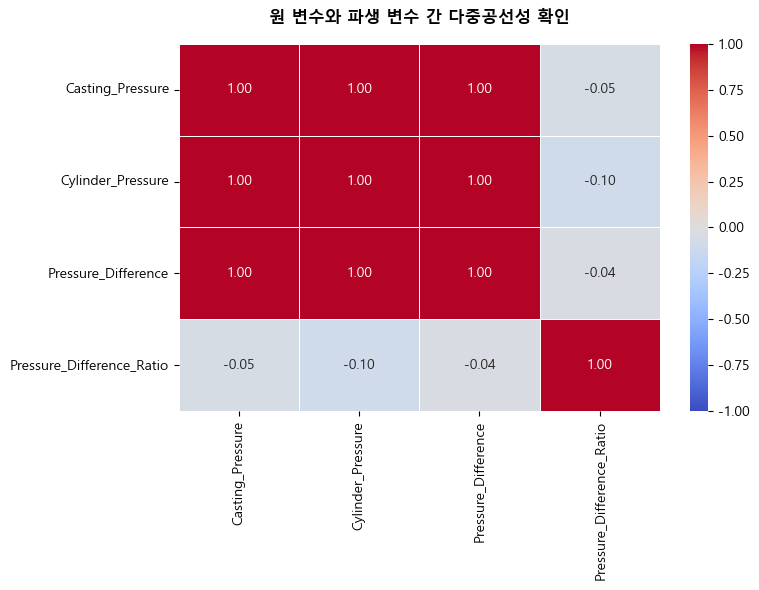

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# 다중공선성 확인 — Casting_Pressure / Cylinder_Pressure / Pressure_Difference / Pressure_Difference_Ratio
high_corr_vars1 = ['Casting_Pressure', 'Cylinder_Pressure', 'Pressure_Difference', 'Pressure_Difference_Ratio']
print("[ 다중공선성 의심 변수 상관관계 ]")

# 상관계수 행렬 계산
corr_matrix = type1_df[high_corr_vars1].corr().round(3)
display(corr_matrix)

# -----------------
# 히트맵 시각화 추가
# -----------------
plt.figure(figsize=(8, 6)) # 히트맵 캔버스 크기 지정

# seaborn heatmap 생성
sns.heatmap(
    corr_matrix, 
    annot=True,            # 각 셀 안에 상관계수 숫자 표시
    cmap='coolwarm',       # 색상 팔레트 (파랑: 음의 상관관계, 빨강: 양의 상관관계)
    vmin=-1, vmax=1,       # 색상 표현 시 기준점 (-1 ~ 1)
    center=0,              # 중앙값을 0으로 맞춰 색상 대비 강조
    fmt='.2f',             # 숫자 표기 형식 (소수점 2자리)
    linewidths=0.5         # 셀 사이 경계선
)

plt.title('원 변수와 파생 변수 간 다중공선성 확인', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


[ 다중공선성 의심 변수 상관관계 ]


,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Velocity_2-1,Velocity_3-2,Velocity_High-3,Velocity_Max-Min
Velocity_1,1.0000,0.8050,0.6520,0.3830,-0.0060,0.0870,0.2960,0.3040
Velocity_2,0.8050,1.0000,0.7180,0.3880,0.5880,-0.0250,0.2910,0.3270
Velocity_3,0.6520,0.7180,1.0000,0.2820,0.3210,0.6780,0.1390,0.2320
High_Velocity,0.3830,0.3880,0.2820,1.0000,0.1320,-0.0050,0.9890,0.9960
Velocity_2-1,-0.0060,0.5880,0.3210,0.1320,1.0000,-0.1600,0.0870,0.1370
Velocity_3-2,0.0870,-0.0250,0.6780,-0.0050,-0.1600,1.0000,-0.1080,-0.0130
Velocity_High-3,0.2960,0.2910,0.1390,0.9890,0.0870,-0.1080,1.0000,0.9930
Velocity_Max-Min,0.3040,0.3270,0.2320,0.9960,0.1370,-0.0130,0.9930,1.0000


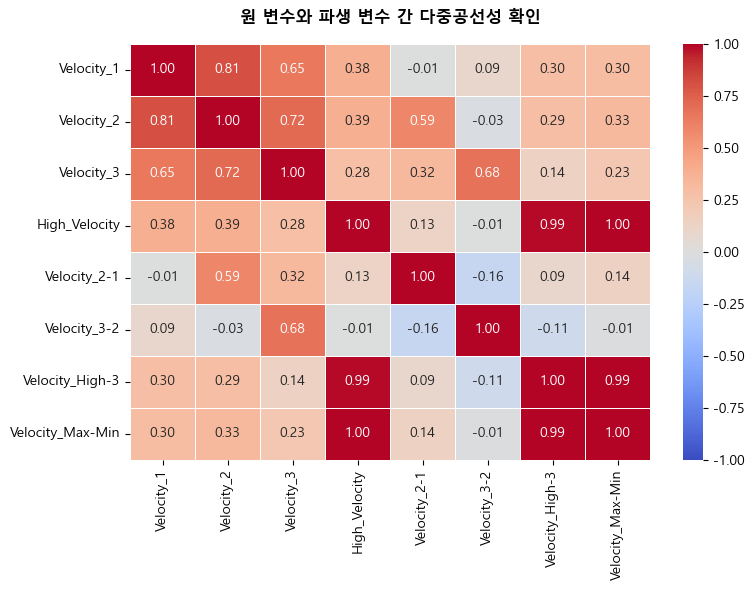

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# 다중공선성 확인 — Casting_Pressure / Cylinder_Pressure / Pressure_Difference / Pressure_Difference_Ratio
high_corr_vars2 = ['Velocity_1', 'Velocity_2', 'Velocity_3',
       'High_Velocity', 'Velocity_2-1', 'Velocity_3-2',
       'Velocity_High-3', 'Velocity_Max-Min']
print("[ 다중공선성 의심 변수 상관관계 ]")

# 상관계수 행렬 계산
corr_matrix = type1_df[high_corr_vars2].corr().round(3)
display(corr_matrix)

# -----------------
# 히트맵 시각화 추가
# -----------------
plt.figure(figsize=(8, 6)) # 히트맵 캔버스 크기 지정

# seaborn heatmap 생성
sns.heatmap(
    corr_matrix, 
    annot=True,            # 각 셀 안에 상관계수 숫자 표시
    cmap='coolwarm',       # 색상 팔레트 (파랑: 음의 상관관계, 빨강: 양의 상관관계)
    vmin=-1, vmax=1,       # 색상 표현 시 기준점 (-1 ~ 1)
    center=0,              # 중앙값을 0으로 맞춰 색상 대비 강조
    fmt='.2f',             # 숫자 표기 형식 (소수점 2자리)
    linewidths=0.5         # 셀 사이 경계선
)

plt.title('원 변수와 파생 변수 간 다중공선성 확인', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


In [50]:
# VIF도 확인

from statsmodels.stats.outliers_influence import variance_inflation_factor

high_corr_vars = ['Velocity_1', 'Velocity_2', 'Velocity_3','High_Velocity', ]

X = type1_df[high_corr_vars]

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_df)

,variable,VIF
0,Velocity_1,4113.6514
1,Velocity_2,4577.1664
2,Velocity_3,1733.3667
3,High_Velocity,1537.5165


In [51]:
# VIF도 확인

from statsmodels.stats.outliers_influence import variance_inflation_factor

high_corr_vars = ['Velocity_2-1', 'Velocity_3-2', 'Velocity_High-3', 'Velocity_Max-Min']

X = type1_df[high_corr_vars]

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_df)

,variable,VIF
0,Velocity_2-1,inf
1,Velocity_3-2,inf
2,Velocity_High-3,inf
3,Velocity_Max-Min,inf


In [52]:
# VIF도 확인

from statsmodels.stats.outliers_influence import variance_inflation_factor

high_corr_vars = ['Velocity_1', 'Velocity_2', 'Velocity_3','High_Velocity']

X = type1_df[high_corr_vars]

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_df)

,variable,VIF
0,Velocity_1,4113.6514
1,Velocity_2,4577.1664
2,Velocity_3,1733.3667
3,High_Velocity,1537.5165


In [53]:
# VIF도 확인

from statsmodels.stats.outliers_influence import variance_inflation_factor

high_corr_vars = ['Casting_Pressure', 'Cylinder_Pressure', 'Pressure_Difference', 'Pressure_Difference_Ratio']

X = type1_df[high_corr_vars]

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_df)

,variable,VIF
0,Casting_Pressure,inf
1,Cylinder_Pressure,inf
2,Pressure_Difference,inf
3,Pressure_Difference_Ratio,869.7618


In [54]:
# VIF도 확인

from statsmodels.stats.outliers_influence import variance_inflation_factor

high_corr_vars = ['Casting_Pressure', 'Cylinder_Pressure']

X = type1_df[high_corr_vars]

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_df)

,variable,VIF
0,Casting_Pressure,351789.8634
1,Cylinder_Pressure,351789.8634


In [55]:
# VIF도 확인

from statsmodels.stats.outliers_influence import variance_inflation_factor

high_corr_vars = ['Pressure_Difference', 'Pressure_Difference_Ratio']

X = type1_df[high_corr_vars]

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_df)

,variable,VIF
0,Pressure_Difference,863.6675
1,Pressure_Difference_Ratio,863.6675


In [56]:
# Velocity 1, 2, 3, High, Pressure_Difference_Ratio만 남기는 것이 VIF를 그나마 줄이면서 가장 현실적이라고 판단!
# 이에 따라 Velocity 구간 별 컬럼과 Casting_Pressure, Cylinder_Pressure, Pressure_Difference는 삭제하기로 결정.

from statsmodels.stats.outliers_influence import variance_inflation_factor

high_corr_vars = ['Velocity_1', 'Velocity_2', 'Velocity_3','High_Velocity','Pressure_Difference_Ratio']

X = type1_df[high_corr_vars]

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_df)

,variable,VIF
0,Velocity_1,4245.6898
1,Velocity_2,4588.3673
2,Velocity_3,1735.2914
3,High_Velocity,2919.7396
4,Pressure_Difference_Ratio,2852.4144


In [57]:
# 결함 컬럼들의 리스트
defect_columns = [
    'Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Stain_1',
    'Dent_1', 'Deformation_1', 'Contamination_1', 'Impurity_1', 'Crack_1',
    'Scratch_1', 'Buring_Mark_1', 'Inclusions_1', 'Short_Shot_2',
    'Bubble_2', 'Exfoliation_2', 'Blow_Hole_2', 'Stain_2', 'Dent_2',
    'Deformation_2', 'Contamination_2', 'Impurity_2', 'Crack_2',
    'Scratch_2', 'Buring_Mark_2', 'Inclusions_2'
]

# 마스킹
has_defect = (type1_df[defect_columns] > 0).any(axis=1)

type1_df['Defect_Status'] = np.where(has_defect, 0, 1)

# 결과 확인
print(type1_df['Defect_Status'].value_counts())
print(type1_df['Defect_Status'].value_counts(normalize=True))


Defect_Status
1    2075
0     576
Name: count, dtype: int64
Defect_Status
1   0.7827
0   0.2173
Name: proportion, dtype: float64


In [58]:
import pandas as pd

defect_columns = [
    'Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Stain_1',
    'Dent_1', 'Deformation_1', 'Contamination_1', 'Impurity_1', 'Crack_1',
    'Scratch_1', 'Buring_Mark_1', 'Inclusions_1', 'Short_Shot_2',
    'Bubble_2', 'Exfoliation_2', 'Blow_Hole_2', 'Stain_2', 'Dent_2',
    'Deformation_2', 'Contamination_2', 'Impurity_2', 'Crack_2',
    'Scratch_2', 'Buring_Mark_2', 'Inclusions_2'
]

# 추가로 제외할 컬럼
## Product type: Product type 기준 데이터 분리 후 필요 없는 컬럼
## Defect_Status: 독립변수에 해당하지 않음
## Defect_Type: 독립변수에 해당하지 않음

additional_excludes = ['Product_Type','Defect_Status', 'Defect_Type', 'Velocity_2-1','Velocity_3-2','Velocity_High-1']

# 두 리스트를 합쳐서 최종 제외 목록 생성
exclude_columns = defect_columns + additional_excludes

# 합쳐진 제외 목록을 기반으로 독립변수 컬럼 생성
independent_columns = [col for col in type1_df.columns if col not in exclude_columns]

X = type1_df[independent_columns] # 독립변수


In [59]:
print(f"독립변수 컬럼 개수: {len(independent_columns)}개")
print(independent_columns)

독립변수 컬럼 개수: 25개
['Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time', 'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time', 'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp', 'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity', 'Pressure_Difference', 'Pressure_Difference_Ratio', 'Velocity_High-3', 'Velocity_Max-Min']


In [60]:
#---------------------
# 1. 정규성 검정
#---------------------
from scipy import stats

results = []
for col in independent_columns:
    stat, p = stats.shapiro(type1_df[col].dropna())
    results.append({
        '변수': col,
        'W통계량': round(stat, 4),
        'p-value': f"{p:.5e}",
        '정규성': '✅' if p > 0.05 else '❌'
    })

display(pd.DataFrame(results))

,변수,W통계량,p-value,정규성
0,Shot,0.9506,5.23643e-29,❌
1,Velocity_1,0.5795,2.53586e-62,❌
2,Velocity_2,0.4157,1.32892e-68,❌
3,Velocity_3,0.7624,3.66698e-52,❌
4,High_Velocity,0.4807,2.58539e-66,❌
5,Cylinder_Pressure,0.5964,1.45790e-61,❌
6,Rapid_Rise_Time,0.5515,1.57354e-63,❌
7,Biscuit_Thickness,0.7065,8.18563e-56,❌
8,Clamping_Force,0.9128,1.42249e-36,❌
9,Cycle_Time,0.0542,2.37503e-78,❌


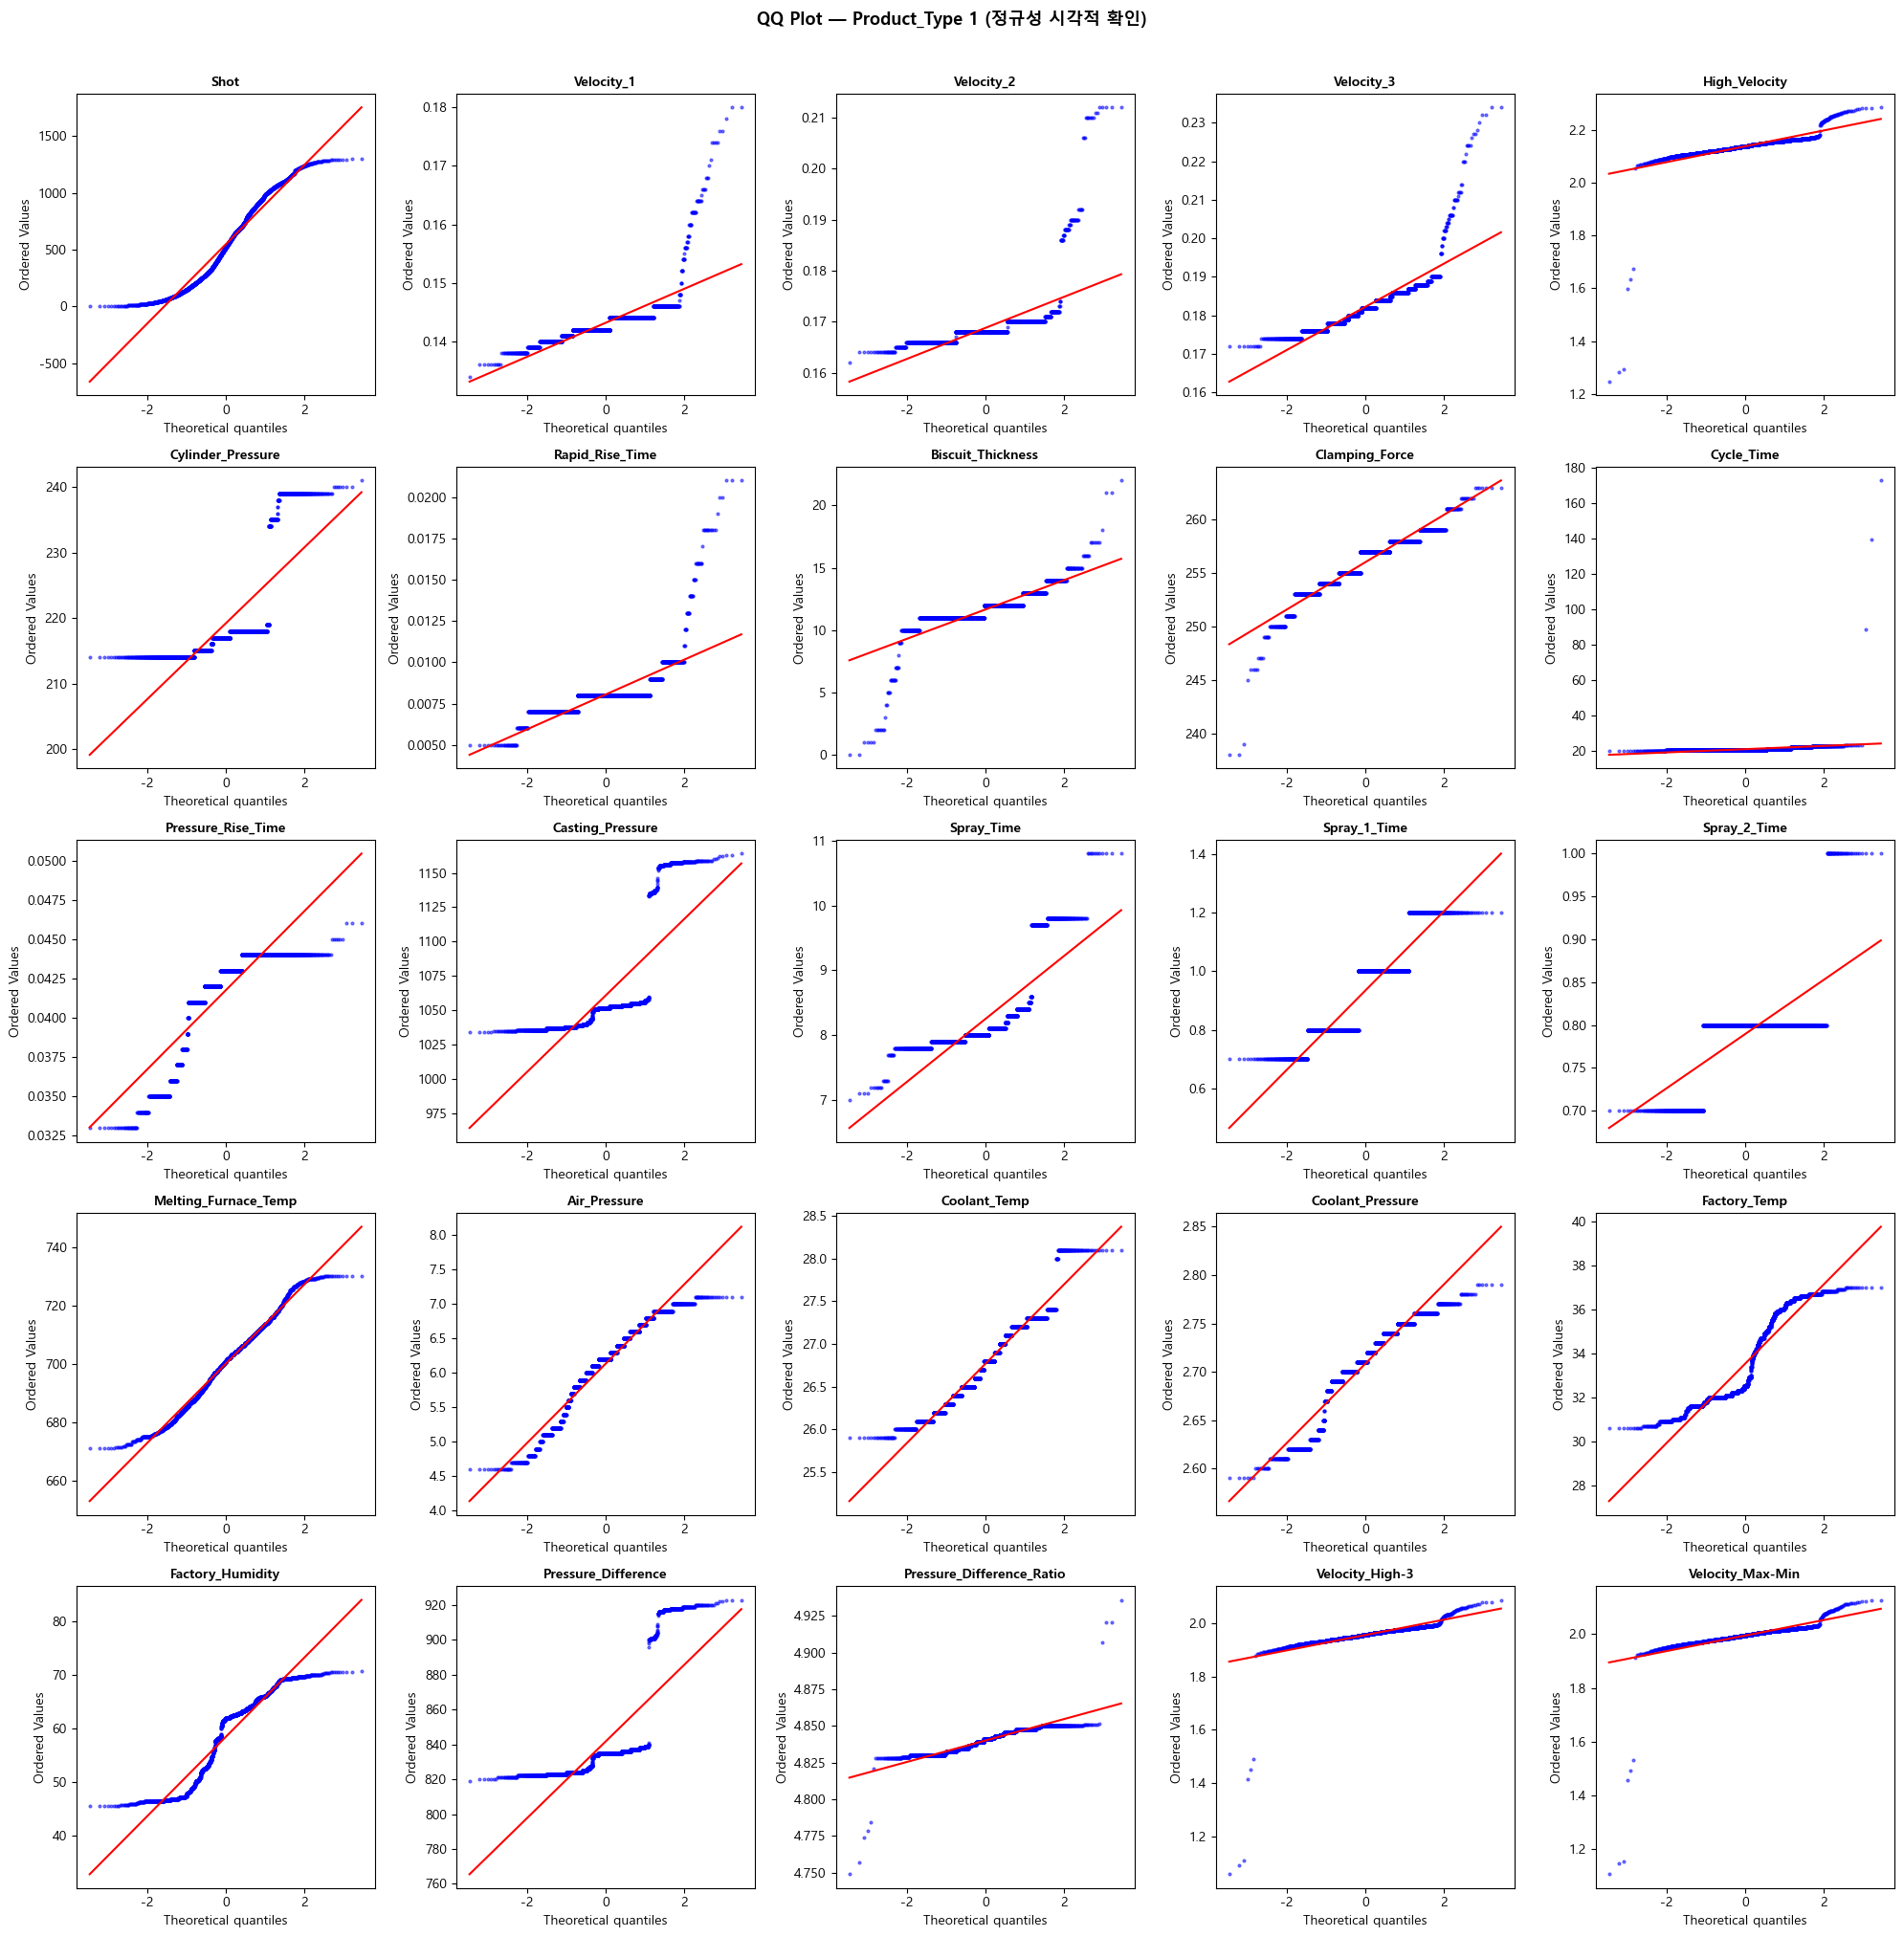

In [61]:
#---------------------
# 1-2. QQ Plot
#---------------------

import scipy.stats as stats
import matplotlib.pyplot as plt
import math

n_vars = len(independent_columns)
n_cols = 5
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(independent_columns):
    stats.probplot(type1_df[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].get_lines()[0].set(markersize=2, alpha=0.5)

# 남는 빈 서브플롯 숨기기
for j in range(n_vars, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('QQ Plot — Product_Type 1 (정규성 시각적 확인)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [62]:
from scipy.stats import spearmanr

results = []

for col in type1_df[independent_columns]:
    clean = type1_df[[col, 'Defect_Status']].dropna()
    corr, p = spearmanr(clean[col], clean['Defect_Status'])
    results.append({
        '변수': col,
        '스피어만 상관계수': round(corr, 4),
        'p-value': round(p, 4),
        '절댓값': round(abs(corr), 4)
})

spearman_df = pd.DataFrame(results).sort_values('절댓값', ascending=False)
spearman_df

,변수,스피어만 상관계수,p-value,절댓값
20,Factory_Humidity,0.2782,0.0000,0.2782
19,Factory_Temp,-0.2155,0.0000,0.2155
7,Biscuit_Thickness,0.1698,0.0000,0.1698
14,Spray_2_Time,-0.1669,0.0000,0.1669
21,Pressure_Difference,0.1276,0.0000,0.1276
11,Casting_Pressure,0.1252,0.0000,0.1252
5,Cylinder_Pressure,0.1207,0.0000,0.1207
9,Cycle_Time,0.1204,0.0000,0.1204
10,Pressure_Rise_Time,-0.0990,0.0000,0.0990
12,Spray_Time,0.0963,0.0000,0.0963


In [63]:
#---------------------
# 2. Mann-Whitney U 검정
#---------------------

from scipy.stats import mannwhitneyu

defect   = type1_df[type1_df['Defect_Status'] == 1]
normal   = type1_df[type1_df['Defect_Status'] == 0]

results = []
for col in independent_columns:
    stat, p = mannwhitneyu(
        defect[col].dropna(),
        normal[col].dropna(),
        alternative='two-sided'
    )
    results.append({
        '변수': col,
        'U통계량': round(stat, 1),
        'p-value': round(p, 4),
        '유의성': '✅' if p < 0.05 else '❌'
    })

result_df = pd.DataFrame(results).sort_values('p-value')
display(result_df)

,변수,U통계량,p-value,유의성
7,Biscuit_Thickness,730253.0000,0.0000,✅
5,Cylinder_Pressure,696170.0000,0.0000,✅
14,Spray_2_Time,508491.5000,0.0000,✅
12,Spray_Time,677032.5000,0.0000,✅
11,Casting_Pressure,702087.0000,0.0000,✅
10,Pressure_Rise_Time,516974.5000,0.0000,✅
9,Cycle_Time,697122.5000,0.0000,✅
8,Clamping_Force,532286.5000,0.0000,✅
20,Factory_Humidity,830336.5000,0.0000,✅
21,Pressure_Difference,703462.0000,0.0000,✅


In [64]:
#---------------------
# 3. 효과크기 계산 (Rank-Biserial Correlation)
#---------------------

from scipy.stats import mannwhitneyu
import numpy as np

def rank_biserial(u_stat, n1, n2):
    return (2 * u_stat) / (n1 * n2) - 1

defect = type1_df[type1_df['Defect_Status'] == 1]
normal = type1_df[type1_df['Defect_Status'] == 0]
n1, n2 = len(defect), len(normal)

results = []
for col in independent_columns:
    stat, p = mannwhitneyu(defect[col].dropna(), normal[col].dropna(), alternative='two-sided')
    r = abs(rank_biserial(stat, n1, n2))
    results.append({
        '변수': col,
        'p-value': round(p, 4),
        '효과크기(r)': round(r, 4),
        '해석': '대' if r >= 0.5 else '중' if r >= 0.3 else '소'
    })

result_df = pd.DataFrame(results).sort_values('효과크기(r)', ascending=False)
display(result_df)

,변수,p-value,효과크기(r),해석
20,Factory_Humidity,0.0000,0.3895,중
19,Factory_Temp,0.0000,0.3013,중
7,Biscuit_Thickness,0.0000,0.2220,소
21,Pressure_Difference,0.0000,0.1771,소
11,Casting_Pressure,0.0000,0.1748,소
9,Cycle_Time,0.0000,0.1665,소
5,Cylinder_Pressure,0.0000,0.1649,소
14,Spray_2_Time,0.0000,0.1491,소
10,Pressure_Rise_Time,0.0000,0.1349,소
12,Spray_Time,0.0000,0.1329,소


In [73]:
#---------------------
# 4. Kruskal-Wallis H 검정 (Defect_Type 별 차이 확인)
#---------------------
from scipy.stats import kruskal
import pandas as pd

results = []

# 결측치가 없으므로 고유한 결함 유형을 바로 추출
defect_types = type1_df['Defect_Type'].dropna().unique()

print(f"✅ 분석 대상 결함 유형: {defect_types}\n")

for col in independent_columns:
    # 각 결함 유형별로 해당 컬럼의 데이터 그룹 리스트 생성
    groups = [type1_df[type1_df['Defect_Type'] == dt][col] for dt in defect_types]
    
    # 조건 확인 없이 바로 Kruskal-Wallis 검정 실행
    stat, p = kruskal(*groups)
    
    results.append({
        '변수': col,
        'H통계량': round(stat, 2),
        'p-value': round(p, 2),
        '유의성': '✅' if p < 0.05 else '❌'
    })

# 데이터프레임 변환 후 p-value를 기준으로 오름차순 정렬
result_df = pd.DataFrame(results).sort_values('p-value')

result_df


✅ 분석 대상 결함 유형: <StringArray>
[     'Normal', 'Exfoliation', 'Deformation',  'Short_Shot',       'Other',
       'Stain',      'Bubble']
Length: 7, dtype: str



,변수,H통계량,p-value,유의성
0,Shot,39.7400,0.0000,✅
7,Biscuit_Thickness,79.9000,0.0000,✅
5,Cylinder_Pressure,43.5700,0.0000,✅
4,High_Velocity,24.2800,0.0000,✅
11,Casting_Pressure,47.6600,0.0000,✅
10,Pressure_Rise_Time,32.8200,0.0000,✅
9,Cycle_Time,45.6800,0.0000,✅
8,Clamping_Force,20.6200,0.0000,✅
12,Spray_Time,35.4800,0.0000,✅
13,Spray_1_Time,38.4600,0.0000,✅


In [74]:
#---------------------
# 5. 효과크기 계산 (Epsilon-squared)
#---------------------
results = []

# type1_df['Defect_Type'] 컬럼에서 결측치를 제외한 유니크(고유)한 결함 유형들을 자동으로 추출
defect_types = type1_df['Defect_Type'].dropna().unique()

for col in independent_columns:
    # 각 독립변수(col)에 대해 결측치(결측값)를 제외한 전체 데이터 수 (효과 크기 계산용)
    # 전체 n_total을 type1_df의 길이로 쓰면 결측치가 많은 변수에서 효과크기가 부정확해질 수 있으므로,
    # 해당 변수(col) 기준에서의 유효한 데이터 개수를 세는 것이 더 정확합니다.
    col_valid_data = type1_df[~type1_df['Defect_Type'].isna()][col].dropna()
    n_total = len(col_valid_data)
    
    # 동적으로 추출한 defect_types를 바탕으로 각각의 그룹 데이터 리스트 생성
    groups = [
        type1_df[type1_df['Defect_Type'] == dt][col].dropna() 
        for dt in defect_types
    ]
    
    # 길이가 0인 그룹 제외
    valid_groups = [g for g in groups if len(g) > 0]
    
    # Kruskal-Wallis 검정 및 효과 크기 계산
    if len(valid_groups) >= 2 and n_total > 1:
        stat, p = kruskal(*valid_groups)
        
        # Epsilon-squared 계산 공식: H / (n^2 - 1) * (n + 1) -> H / (n - 1)
        eps_sq = stat / (n_total - 1)
        
        results.append({
            '변수': col,
            'H통계량': round(stat, 2),
            'p-value': round(p, 4),
            'ε²': round(eps_sq, 4),
            '해석': '대' if eps_sq >= 0.14 else '중' if eps_sq >= 0.06 else '소'
        })
    else:
        results.append({
            '변수': col,
            'H통계량': None,
            'p-value': '비교 그룹 부족 또는 데이터 부족',
            'ε²': None,
            '해석': '-'
        })

result_df = pd.DataFrame(results)

# ε²(에타 제곱)을 기준으로 내림차순 정렬 (결측치(None) 대비 안전하게 정렬)
result_df = result_df.sort_values(by='ε²', ascending=False, na_position='last')

result_df


,변수,H통계량,p-value,ε²,해석
20,Factory_Humidity,276.7100,0.0000,0.1044,중
19,Factory_Temp,224.0900,0.0000,0.0846,중
7,Biscuit_Thickness,79.9000,0.0000,0.0302,소
14,Spray_2_Time,74.2900,0.0000,0.0280,소
17,Coolant_Temp,72.7200,0.0000,0.0274,소
21,Pressure_Difference,49.5500,0.0000,0.0187,소
11,Casting_Pressure,47.6600,0.0000,0.0180,소
18,Coolant_Pressure,45.8500,0.0000,0.0173,소
9,Cycle_Time,45.6800,0.0000,0.0172,소
5,Cylinder_Pressure,43.5700,0.0000,0.0164,소


In [75]:
#---------------------
# 6. 사후검정 (Dunn's Test)
#---------------------
import scikit_posthocs as sp
import pandas as pd
import numpy as np

# 앞서 정의했던 분석 대상 결함군 리스트 자동 추출
defect_types = type1_df['Defect_Type'].dropna().unique()

# final_vars 대신 independent_columns (또는 유의미하게 나온 변수 리스트)를 순회하도록 변경
for col in independent_columns:
    print(f'\n--- {col} ---')
    
    # 1. 해당 독립변수(col)와 그룹변수(Defect_Type)에 결측치가 없는 데이터만 1차로 필터링
    # Dunn's Test는 결측치가 그룹에 엉켜있으면 잘못된 자유도/결과를 낼 수 있음
    valid_df = type1_df[[col, 'Defect_Type']].dropna()
    
    # 2. 방금 추출한 defect_types에 해당하는 데이터인지 한 번 더 명확히 확인
    valid_df = valid_df[valid_df['Defect_Type'].isin(defect_types)]
        
    # 3. Dunn's Test 수행
    dunn = sp.posthoc_dunn(
        valid_df,
        val_col=col,
        group_col='Defect_Type',
        p_adjust='bonferroni'
    )
    
    # 결과를 읽기 편하게 4자리 반올림 (너무 작은 값은 지수 표현이 아닌 0.0000으로 표시 됨)
    # 만약 이 표에서도 0.0000보다 더 자세히 보고 싶다면 round(4)를 지우셔도 됩니다.
    print(dunn.round(4))
        
    



--- Shot ---
             Bubble  Deformation  Exfoliation  Normal  Other  Short_Shot  \
Bubble       1.0000       1.0000       0.0000  0.0601 1.0000      0.1154   
Deformation  1.0000       1.0000       0.0000  0.3051 1.0000      0.8165   
Exfoliation  0.0000       0.0000       1.0000  0.0001 1.0000      0.0574   
Normal       0.0601       0.3051       0.0001  1.0000 1.0000      1.0000   
Other        1.0000       1.0000       1.0000  1.0000 1.0000      1.0000   
Short_Shot   0.1154       0.8165       0.0574  1.0000 1.0000      1.0000   
Stain        1.0000       1.0000       1.0000  1.0000 1.0000      1.0000   

             Stain  
Bubble      1.0000  
Deformation 1.0000  
Exfoliation 1.0000  
Normal      1.0000  
Other       1.0000  
Short_Shot  1.0000  
Stain       1.0000  

--- Velocity_1 ---
             Bubble  Deformation  Exfoliation  Normal  Other  Short_Shot  \
Bubble       1.0000       1.0000       1.0000  1.0000 1.0000      1.0000   
Deformation  1.0000       1.0000     

In [69]:
independent_columns

['Shot',
 'Velocity_1',
 'Velocity_2',
 'Velocity_3',
 'High_Velocity',
 'Cylinder_Pressure',
 'Rapid_Rise_Time',
 'Biscuit_Thickness',
 'Clamping_Force',
 'Cycle_Time',
 'Pressure_Rise_Time',
 'Casting_Pressure',
 'Spray_Time',
 'Spray_1_Time',
 'Spray_2_Time',
 'Melting_Furnace_Temp',
 'Air_Pressure',
 'Coolant_Temp',
 'Coolant_Pressure',
 'Factory_Temp',
 'Factory_Humidity',
 'Pressure_Difference',
 'Pressure_Difference_Ratio',
 'Velocity_High-3',
 'Velocity_Max-Min']


--- [ Velocity_Max-Min ] 사후검정 p-value 히트맵 ---


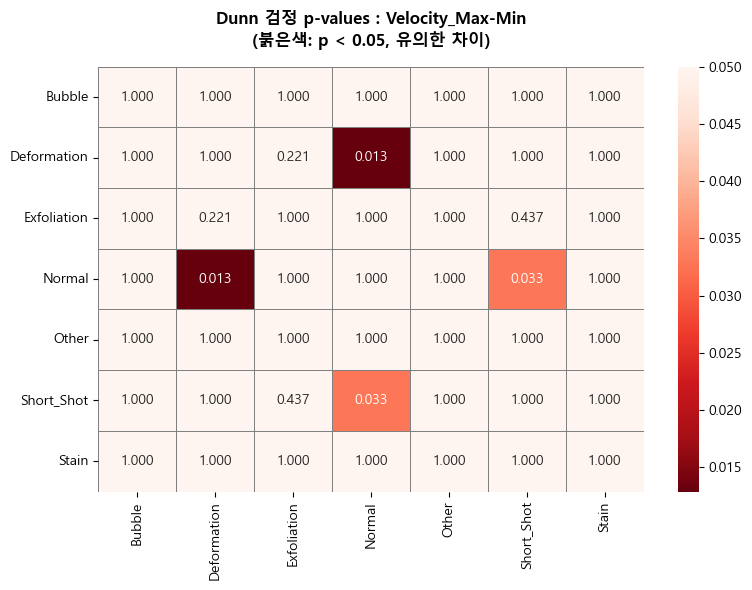

In [102]:
# ---------------------
# [추가] 사후검정 결과 시각화 (Heatmap)
# ---------------------
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 모든 컬럼에 대해 시각화하면 그래프가 너무 많아지므로,
# 위에서 사후검정을 돌렸던 independent_columns 중,
# 보고자 하는 특정 변수(col)를 하나 골라서 시각화하는 예시입니다.
# 여기서는 independent_columns의 첫 번째 변수를 예시로 가져옵니다.
col_to_visualize = independent_columns[24] # 원하는 변수로 변경 가능 (예: 'Velocity_1', 'Cycle_Time' 등)

print(f'\n--- [ {col_to_visualize} ] 사후검정 p-value 히트맵 ---')

# 해당 변수에 대해 다시 한 번 Dunn's Test 계산 (시각화용)
valid_df = type1_df[[col_to_visualize, 'Defect_Type']].dropna()
valid_df = valid_df[valid_df['Defect_Type'].isin(defect_types)]


dunn_matrix = sp.posthoc_dunn(
    valid_df,
    val_col=col_to_visualize,
    group_col='Defect_Type',
    p_adjust='bonferroni'
)

# 히트맵 그리기
plt.figure(figsize=(8, 6))

# 0.05 기준선 강조를 위해 마스킹 처리 (선택사항)
# p-value가 0.05 미만인 곳은 색을 칠하고, 0.05 이상인 곳은 하얗게 둡니다.
# sns.heatmap의 파라미터로 mask를 쓰거나 색상 팔레트를 조절합니다.

# 색상맵 설정 (p-value는 작을수록 유의함 -> 작은 값을 붉은색으로 강조)
# 0에 가까우면 진한 빨강, 0.05를 넘어가면 하얀색(파란색)으로 표현
cmap = sns.color_palette("Reds_r", as_cmap=True) # Reds_r 은 빨간색을 뒤집어 0에 가까울수록 진하게

# annot=True 로 숫자 표시, fmt='.3f' 로 소수점 3자리 표시
ax = sns.heatmap(dunn_matrix, annot=True, cmap=cmap, fmt=".3f", 
                    vmax=0.05,  # 0.05를 최대치로 잡아 그 이상은 유의하지 않은 것으로 처리
                    linewidths=0.5, linecolor='gray')

plt.title(f"Dunn 검정 p-values : {col_to_visualize}\n(붉은색: p < 0.05, 유의한 차이)", 
            fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


